In [1]:
!pip install -q mlflow
!pip install -q --no-cache-dir --force-reinstall --no-deps git+https://github.com/RayenSansa03/aeroguard.git@main

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 89.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 66.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.7/148.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.

In [2]:
print("--- metier.py sur GitHub (main) ---")
!curl -s https://raw.githubusercontent.com/RayenSansa03/aeroguard/main/src/aeroguard/metier.py | grep -n "^def "
print("\n--- metier.py installé dans Colab ---")
!grep -n "^def " $(python -c "import aeroguard, os; print(os.path.dirname(aeroguard.__file__))")/metier.py

--- metier.py sur GitHub (main) ---
7:def alertes_confirmees(alertes, k=1):
15:def avance_alerte(alertes, y, rul, k=1):
24:def fausses_alarmes(alertes, y, k=1):
30:def bilan_flotte(table, col_moteur="unit", col_ordre="cycle", col_rul="RUL", k=1):
47:def resume_flotte(bilan):
59:def diagnostic_par_moteur(moteurs, predictions):
65:def evaluer_alerte(
84:def evaluer_alerte_score(

--- metier.py installé dans Colab ---
7:def alertes_confirmees(alertes, k=1):
15:def avance_alerte(alertes, y, rul, k=1):
24:def fausses_alarmes(alertes, y, k=1):
30:def bilan_flotte(table, col_moteur="unit", col_ordre="cycle", col_rul="RUL", k=1):
47:def resume_flotte(bilan):
59:def diagnostic_par_moteur(moteurs, predictions):
65:def evaluer_alerte(
84:def evaluer_alerte_score(


In [5]:
from google.colab import drive
drive.mount("/content/drive")

import json
import math
import os
import shutil

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
from tensorflow import keras

from aeroguard.autoencodeurs import erreur_reconstruction, standardiser
from aeroguard.donnees_ml import preparer_xy

DOSSIER = "/content/drive/MyDrive/aeroguard"
DOSSIER_MLFLOW_LOCAL = "/content/mlflow"
DOSSIER_MLFLOW_DRIVE = f"{DOSSIER}/mlflow"
if os.path.exists(DOSSIER_MLFLOW_DRIVE) and not os.path.exists(DOSSIER_MLFLOW_LOCAL):
    shutil.copytree(DOSSIER_MLFLOW_DRIVE, DOSSIER_MLFLOW_LOCAL)
if os.path.exists(f"{DOSSIER}/mlruns") and not os.path.exists("/content/mlruns"):
    shutil.copytree(f"{DOSSIER}/mlruns", "/content/mlruns")
os.makedirs(DOSSIER_MLFLOW_LOCAL, exist_ok=True)
mlflow.set_tracking_uri(f"sqlite:///{DOSSIER_MLFLOW_LOCAL}/mlflow.db")

vols = pd.read_parquet(f"{DOSSIER}/data/processed/vols_ncmapss.parquet")
X_train, y_train = preparer_xy(vols, "train")
X_val, y_val = preparer_xy(vols, "val")
infos_val = vols.loc[X_val.index, ["moteur", "cycle", "RUL"]]
sains_train = (y_train == 0).to_numpy()
sains_val = (y_val == 0).to_numpy()

# L'autoencodeur et SA référence « normale » sauvegardés en 5.1
autoencodeur = keras.models.load_model(f"{DOSSIER}/models/autoencodeur_dense_v5.keras")
stats = np.load(f"{DOSSIER}/models/autoencodeur_dense_v5_stats.npz", allow_pickle=True)  # fichier créé par nous en 5.1
colonnes = [str(c) for c in stats["colonnes"]]
assert colonnes == list(X_train.columns), "Les colonnes ne correspondent pas à la 5.1."


def preparer(X):
    """Même préparation qu'en 5.1 : imputation par la médiane du train, puis standardisation."""
    valeurs = X[colonnes].to_numpy(dtype="float64")
    valeurs = np.where(np.isnan(valeurs), stats["medianes_imputation"], valeurs)
    return standardiser(valeurs, stats["moyennes"], stats["ecarts"])


erreurs_val = erreur_reconstruction(autoencodeur, preparer(X_val))
erreurs_train_sains = erreur_reconstruction(autoencodeur, preparer(X_train)[sains_train])
print(f"Erreur médiane — sains val : {np.median(erreurs_val[sains_val]):.3f} (5.1 : 0.195) | "
      f"usés val : {np.median(erreurs_val[~sains_val]):.3f} (5.1 : 1.203)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Erreur médiane — sains val : 0.195 (5.1 : 0.195) | usés val : 1.203 (5.1 : 1.203)


In [6]:
from aeroguard.anomalies import seuil_percentile

POURCENTAGES = [90, 95, 97.5, 99]
seuils = pd.DataFrame({
    "seuil_sains_validation": {p: seuil_percentile(erreurs_val[sains_val], p) for p in POURCENTAGES},
    "seuil_sains_train": {p: seuil_percentile(erreurs_train_sains, p) for p in POURCENTAGES},
})
seuils["alertes_vols_sains_val_si_seuil_train"] = [
    (erreurs_val[sains_val] > s).mean() for s in seuils["seuil_sains_train"]
]
seuils.index.name = "percentile"
print("Si on calibrait sur le TRAIN, quelle part des vols sains de validation sonnerait ?")
seuils.round(3)

Si on calibrait sur le TRAIN, quelle part des vols sains de validation sonnerait ?


,seuil_sains_validation,seuil_sains_train,alertes_vols_sains_val_si_seuil_train
percentile,,,
90.0,0.451,0.331,0.209
95.0,0.499,0.396,0.139
97.5,0.789,0.496,0.053
99.0,1.254,0.663,0.029


In [7]:
from aeroguard.metier import evaluer_alerte_score

lignes = []
for p in POURCENTAGES:
    seuil = seuils.loc[p, "seuil_sains_validation"]
    for k in (1, 3, 5):
        scores = evaluer_alerte_score(y_val, erreurs_val, seuil, infos_val, k=k, col_moteur="moteur")
        lignes.append({"percentile": p, "k": k, "seuil": seuil, **scores})
balayage = pd.DataFrame(lignes)

colonnes_vues = ["percentile", "k", "seuil", "f1_macro", "rappel", "precision", "moteurs_detectes",
                 "avance_moyenne", "fausses_alarmes_total", "moteurs_avec_fausse_alarme"]
balayage[colonnes_vues].round(3)

,percentile,k,seuil,f1_macro,rappel,precision,moteurs_detectes,avance_moyenne,fausses_alarmes_total,moteurs_avec_fausse_alarme
0,90.0,1,0.451,0.764,0.727,0.944,11,44.455,25,7
1,90.0,3,0.451,0.764,0.727,0.944,11,33.182,3,3
2,90.0,5,0.451,0.764,0.727,0.944,11,29.182,0,0
3,95.0,1,0.499,0.772,0.713,0.969,11,44.091,13,5
4,95.0,3,0.499,0.772,0.713,0.969,11,32.455,1,1
5,95.0,5,0.499,0.772,0.713,0.969,11,28.545,0,0
6,97.5,1,0.789,0.704,0.598,0.980,11,36.909,7,4
7,97.5,3,0.789,0.704,0.598,0.980,11,26.091,0,0
8,97.5,5,0.789,0.704,0.598,0.980,11,23.727,0,0
9,99.0,1,1.254,0.641,0.496,0.990,11,30.000,3,3


In [8]:

candidats = balayage[balayage["moteurs_detectes"] == balayage["moteurs"]]
assert len(candidats) > 0, "Aucun réglage ne prévient tous les moteurs."
choix = candidats.sort_values(["fausses_alarmes_total", "avance_moyenne"],
                              ascending=[True, False]).iloc[0]

CONFIG_AE = {
    "percentile": float(choix["percentile"]),
    "seuil": float(choix["seuil"]),
    "k": int(choix["k"]),
    "calibre_sur": "erreurs de reconstruction des vols sains de validation",
}
with open(f"{DOSSIER}/models/autoencodeur_dense_v5_alerte.json", "w") as f:
    json.dump(CONFIG_AE, f, indent=2)
print("Configuration figée :", CONFIG_AE)
choix[colonnes_vues]

Configuration figée : {'percentile': 90.0, 'seuil': 0.4505910873413086, 'k': 5, 'calibre_sur': 'erreurs de reconstruction des vols sains de validation'}


,2
percentile,90.000000
k,5.000000
seuil,0.450591
f1_macro,0.763835
rappel,0.726957
precision,0.943567
moteurs_detectes,11.000000
avance_moyenne,29.181818
fausses_alarmes_total,0.000000
moteurs_avec_fausse_alarme,0.000000


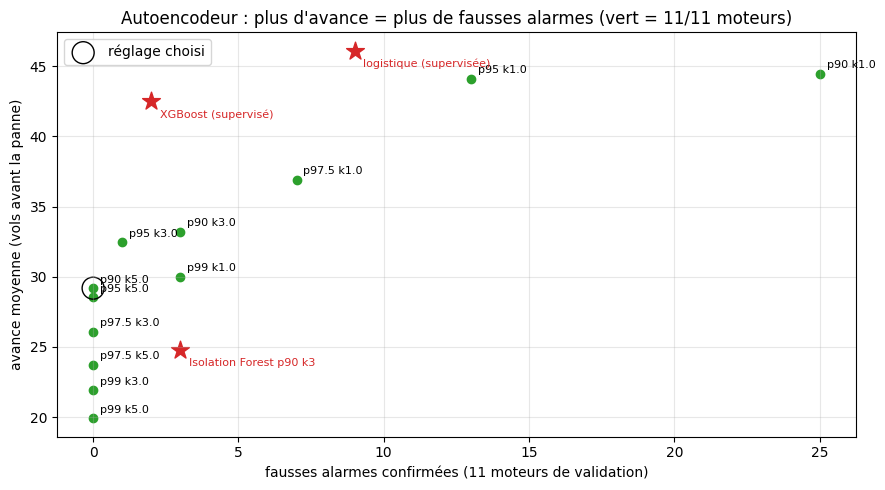

In [9]:
plt.figure(figsize=(9, 5))
for _, ligne in balayage.iterrows():
    couleur = "tab:green" if ligne["moteurs_detectes"] == ligne["moteurs"] else "tab:gray"
    plt.scatter(ligne["fausses_alarmes_total"], ligne["avance_moyenne"], color=couleur)
    plt.annotate(f"p{ligne['percentile']:g} k{ligne['k']}",
                 (ligne["fausses_alarmes_total"], ligne["avance_moyenne"]),
                 textcoords="offset points", xytext=(5, 4), fontsize=8)
references = {"XGBoost (supervisé)": (2, 42.5), "logistique (supervisée)": (9, 46.1),
              "Isolation Forest p90 k3": (3, 24.8)}
for nom, (fa, avance) in references.items():
    plt.scatter(fa, avance, marker="*", s=180, color="tab:red")
    plt.annotate(nom, (fa, avance), textcoords="offset points", xytext=(6, -12), fontsize=8, color="tab:red")
plt.scatter(CONFIG_AE and choix["fausses_alarmes_total"], choix["avance_moyenne"],
            s=250, facecolors="none", edgecolors="black", label="réglage choisi")
plt.xlabel("fausses alarmes confirmées (11 moteurs de validation)")
plt.ylabel("avance moyenne (vols avant la panne)")
plt.title("Autoencodeur : plus d'avance = plus de fausses alarmes (vert = 11/11 moteurs)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{DOSSIER}/results/figures/52_compromis_seuil.png", dpi=150)
plt.show()

In [10]:
face_a_face = pd.DataFrame({
    "a_vu_des_pannes": ["oui", "oui", "non", "non"],
    "moteurs_detectes": [11, 11, 11, int(choix["moteurs_detectes"])],
    "avance_moyenne": [42.5, 46.1, 24.8, choix["avance_moyenne"]],
    "fausses_alarmes_total": [2, 9, 3, int(choix["fausses_alarmes_total"])],
}, index=["XGBoost (v3)", "logistique (v2)", "Isolation Forest p90 k3 (v2)",
          f"autoencodeur p{CONFIG_AE['percentile']:g} k{CONFIG_AE['k']} (5.2)"])
face_a_face.round(1)

,a_vu_des_pannes,moteurs_detectes,avance_moyenne,fausses_alarmes_total
XGBoost (v3),oui,11,42.5,2
logistique (v2),oui,11,46.1,9
Isolation Forest p90 k3 (v2),non,11,24.8,3
autoencodeur p90 k5 (5.2),non,11,29.2,0


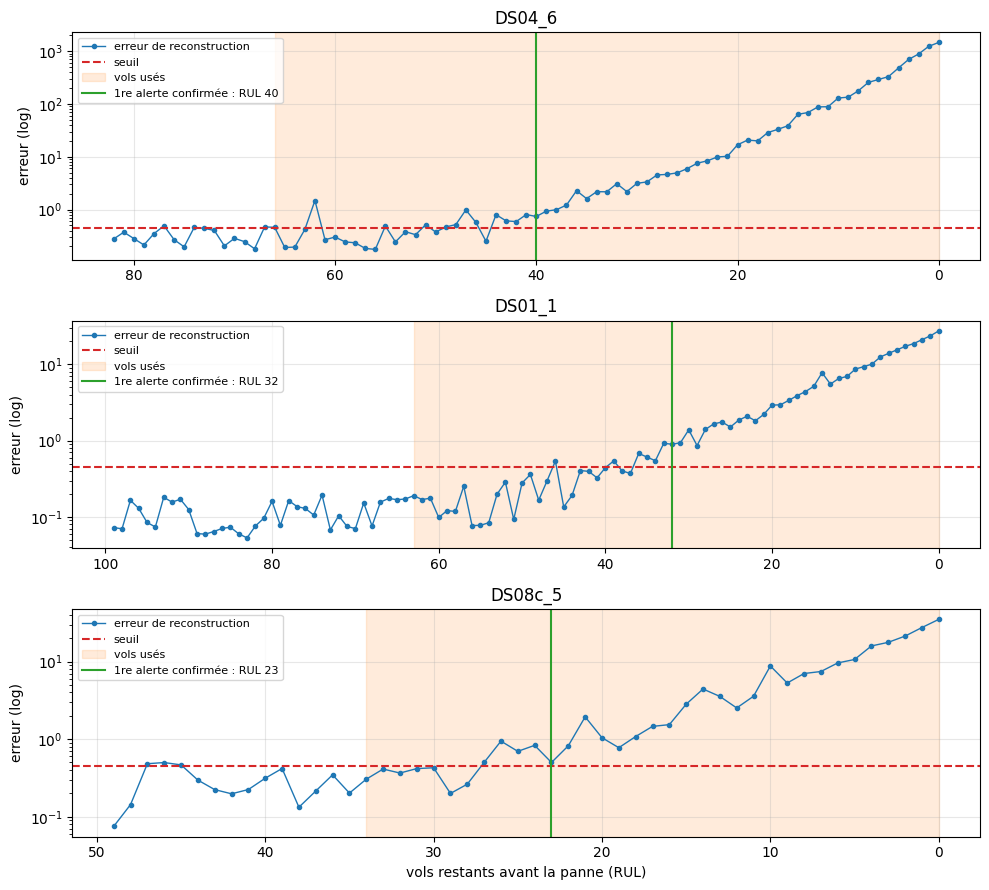

In [11]:
from aeroguard.anomalies import alertes
from aeroguard.metier import alertes_confirmees

suivi = infos_val.assign(erreur=erreurs_val, y=y_val.to_numpy())
MOTEURS = ["DS04_6", "DS01_1", "DS08c_5"]

figure, axes = plt.subplots(len(MOTEURS), 1, figsize=(10, 9))
for axe, moteur in zip(axes, MOTEURS):
    g = suivi[suivi["moteur"] == moteur].sort_values("cycle")
    confirmees = alertes_confirmees(alertes(g["erreur"], CONFIG_AE["seuil"]), k=CONFIG_AE["k"])
    axe.plot(g["RUL"], g["erreur"], marker=".", linewidth=1, label="erreur de reconstruction")
    axe.axhline(CONFIG_AE["seuil"], color="tab:red", linestyle="--", label="seuil")
    debut_usure = g.loc[g["y"] == 1, "RUL"].max()
    axe.axvspan(debut_usure, g["RUL"].min(), color="tab:orange", alpha=0.15, label="vols usés")
    positions = np.where(confirmees == 1)[0]
    if len(positions):
        premiere = g["RUL"].iloc[positions[0]]
        axe.axvline(premiere, color="tab:green", label=f"1re alerte confirmée : RUL {premiere:.0f}")
    axe.invert_xaxis()
    axe.set_yscale("log")
    axe.set_title(moteur)
    axe.set_ylabel("erreur (log)")
    axe.legend(fontsize=8, loc="upper left")
    axe.grid(alpha=0.3)
axes[-1].set_xlabel("vols restants avant la panne (RUL)")
plt.tight_layout()
plt.savefig(f"{DOSSIER}/results/figures/52_alerte_par_moteur.png", dpi=150)
plt.show()

In [12]:
def scores_numeriques(scores):
    """Garde seulement les nombres valides (MLflow refuse le texte et les NaN)."""
    propres = {}
    for cle, valeur in scores.items():
        try:
            nombre = float(valeur)
        except (TypeError, ValueError):
            continue
        if not math.isnan(nombre):
            propres[cle] = nombre
    return propres


bilan_choisi = evaluer_alerte_score(y_val, erreurs_val, CONFIG_AE["seuil"], infos_val,
                                    k=CONFIG_AE["k"], col_moteur="moteur")
balayage.to_csv(f"{DOSSIER}/results/v5_balayage_seuil_autoencodeur.csv", index=False)

mlflow.set_experiment("aeroguard-alerte")
with mlflow.start_run(run_name="autoencodeur_alerte") as run:
    mlflow.log_params({"modele": "autoencodeur_dense", "type": "non supervisé",
                       "percentile": CONFIG_AE["percentile"], "seuil": round(CONFIG_AE["seuil"], 4),
                       "fenetre_confirmation": CONFIG_AE["k"], "calibre_sur": CONFIG_AE["calibre_sur"]})
    mlflow.log_metrics(scores_numeriques(bilan_choisi))
    for chemin in [f"{DOSSIER}/results/figures/52_compromis_seuil.png",
                   f"{DOSSIER}/results/figures/52_alerte_par_moteur.png",
                   f"{DOSSIER}/results/v5_balayage_seuil_autoencodeur.csv",
                   f"{DOSSIER}/models/autoencodeur_dense_v5_alerte.json"]:
        mlflow.log_artifact(chemin)
    mlflow.set_tags({"lecon": "5.2", "tache": "alerte", "jeu": "validation"})
print("✅ Run enregistré :", run.info.run_id[:8])

✅ Run enregistré : 79591c62


In [13]:
dossiers_artifacts = set()
for experience in mlflow.search_experiments():
    emplacement = experience.artifact_location.replace("file://", "")
    if emplacement.startswith("/content") and not emplacement.startswith("/content/drive"):
        dossiers_artifacts.add(os.path.dirname(emplacement))

shutil.copytree(DOSSIER_MLFLOW_LOCAL, DOSSIER_MLFLOW_DRIVE, dirs_exist_ok=True)
for dossier in dossiers_artifacts:
    if os.path.exists(dossier):
        shutil.copytree(dossier, f"{DOSSIER}/{os.path.basename(dossier)}", dirs_exist_ok=True)
print("✅ MLflow sauvegardé sur Drive")

✅ MLflow sauvegardé sur Drive
